In [4]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn import tree
from sklearn import metrics

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
path_dataset = "/content/drive/MyDrive/Dataset/Obesity_Dataset.xlsx"
df = pd.read_excel(path_dataset)
df.head()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4,2
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3,2
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4,2
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4,2
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Sex                                1610 non-null   int64
 1   Age                                1610 non-null   int64
 2   Height                             1610 non-null   int64
 3   Overweight_Obese_Family            1610 non-null   int64
 4   Consumption_of_Fast_Food           1610 non-null   int64
 5   Frequency_of_Consuming_Vegetables  1610 non-null   int64
 6   Number_of_Main_Meals_Daily         1610 non-null   int64
 7   Food_Intake_Between_Meals          1610 non-null   int64
 8   Smoking                            1610 non-null   int64
 9   Liquid_Intake_Daily                1610 non-null   int64
 10  Calculation_of_Calorie_Intake      1610 non-null   int64
 11  Physical_Excercise                 1610 non-null   int64
 12  Schedule_Dedicated_t

In [9]:
df.shape

(1610, 15)

In [10]:
#cek data double
print ('Jumlah data double =', df.duplicated().sum())

Jumlah data double = 0


In [11]:
df.describe()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1.557764,33.115528,167.741615,1.834783,1.729193,2.063354,1.872050,2.395652,1.69441,2.108696,1.822360,3.265839,2.012422,2.667081,2.678882
std,0.496806,9.835076,7.979873,0.371492,0.444515,0.746043,0.638345,1.010501,0.46080,0.814710,0.382328,1.343035,0.697929,1.518388,0.815855
min,1.000000,18.000000,150.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,25.000000,161.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.00000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000
50%,2.000000,32.000000,168.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000
75%,2.000000,41.000000,174.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.00000,3.000000,2.000000,4.000000,2.000000,4.000000,3.000000
max,2.000000,54.000000,193.000000,2.000000,2.000000,3.000000,3.000000,4.000000,2.00000,3.000000,2.000000,5.000000,3.000000,5.000000,4.000000


In [12]:
#cek nilai kosong
df.isnull().sum()

,0
Sex,0
Age,0
Height,0
Overweight_Obese_Family,0
Consumption_of_Fast_Food,0
Frequency_of_Consuming_Vegetables,0
Number_of_Main_Meals_Daily,0
Food_Intake_Between_Meals,0
Smoking,0
Liquid_Intake_Daily,0


In [13]:
#deskripsi dari setiap kolom dalam dataset
df_items = []
for col in df.columns:
    df_items.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col]))*100,2),
                      df[col].nunique(), list(df[col].sample(30).drop_duplicates().values)])

dfDesc = pd.DataFrame(columns=['feature', 'type_data', 'null', '%null', 'unique', 'uniqueSample'],data=df_items)
dfDesc

,feature,type_data,null,%null,unique,uniqueSample
0,Sex,int64,0,0.0,2,"[1, 2]"
1,Age,int64,0,0.0,37,"[40, 42, 22, 52, 20, 44, 27, 34, 32, 21, 26, 2..."
2,Height,int64,0,0.0,42,"[159, 156, 172, 168, 162, 157, 175, 158, 169, ..."
3,Overweight_Obese_Family,int64,0,0.0,2,"[2, 1]"
4,Consumption_of_Fast_Food,int64,0,0.0,2,"[2, 1]"
5,Frequency_of_Consuming_Vegetables,int64,0,0.0,3,"[3, 1, 2]"
6,Number_of_Main_Meals_Daily,int64,0,0.0,3,"[1, 3, 2]"
7,Food_Intake_Between_Meals,int64,0,0.0,4,"[3, 2, 1, 4]"
8,Smoking,int64,0,0.0,2,"[1, 2]"
9,Liquid_Intake_Daily,int64,0,0.0,3,"[2, 3, 1]"


In [14]:
#validasi dataset
if df.isna().sum().sum() > 0:
    print("Dataset masih memiliki nilai kosong, periksa kembali!")
else:
    print("Dataset bersih, siap digunakan untuk pemodelan!")

Dataset bersih, siap digunakan untuk pemodelan!


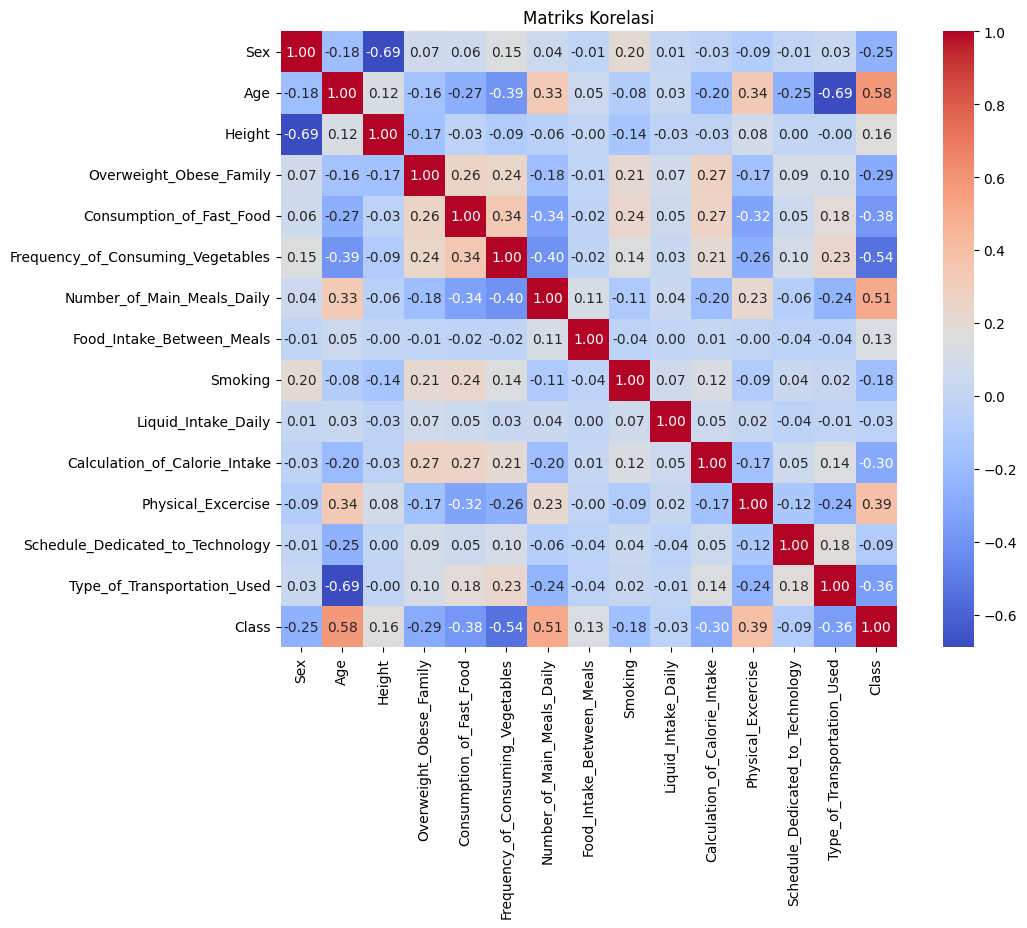

In [15]:
# Visualisasi matriks korelasi
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()  # Menghitung korelasi antar kolom numerik
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriks Korelasi')
plt.show()

Atribut dengan korelasi rendah terhadap target tidak memberikan informasi signifikan untuk prediksi. Maka dilakukan penghapusan untuk atribut-atribut dengan korelasi rendah terhadap Class.

In [16]:
# Buang fitur yg memiliki korelasi rendah
df_fix = df.drop(columns=['Sex', 'Height', 'Overweight_Obese_Family', 'Food_Intake_Between_Meals', 'Smoking', 'Liquid_Intake_Daily', 'Calculation_of_Calorie_Intake', 'Schedule_Dedicated_to_Technology', 'Type_of_Transportation_Used'])
print("Fitur yg dipilih : ")
df_fix # data untuk membuat model

Fitur yg dipilih : 


,Age,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Physical_Excercise,Class
0,18,2,3,1,3,2
1,18,2,3,1,1,2
2,18,2,2,1,2,2
3,18,2,2,2,1,2
4,18,1,2,1,3,2
...,...,...,...,...,...,...
1605,51,1,1,3,3,4
1606,51,1,2,2,5,4
1607,52,2,1,3,4,4
1608,53,1,1,3,2,4


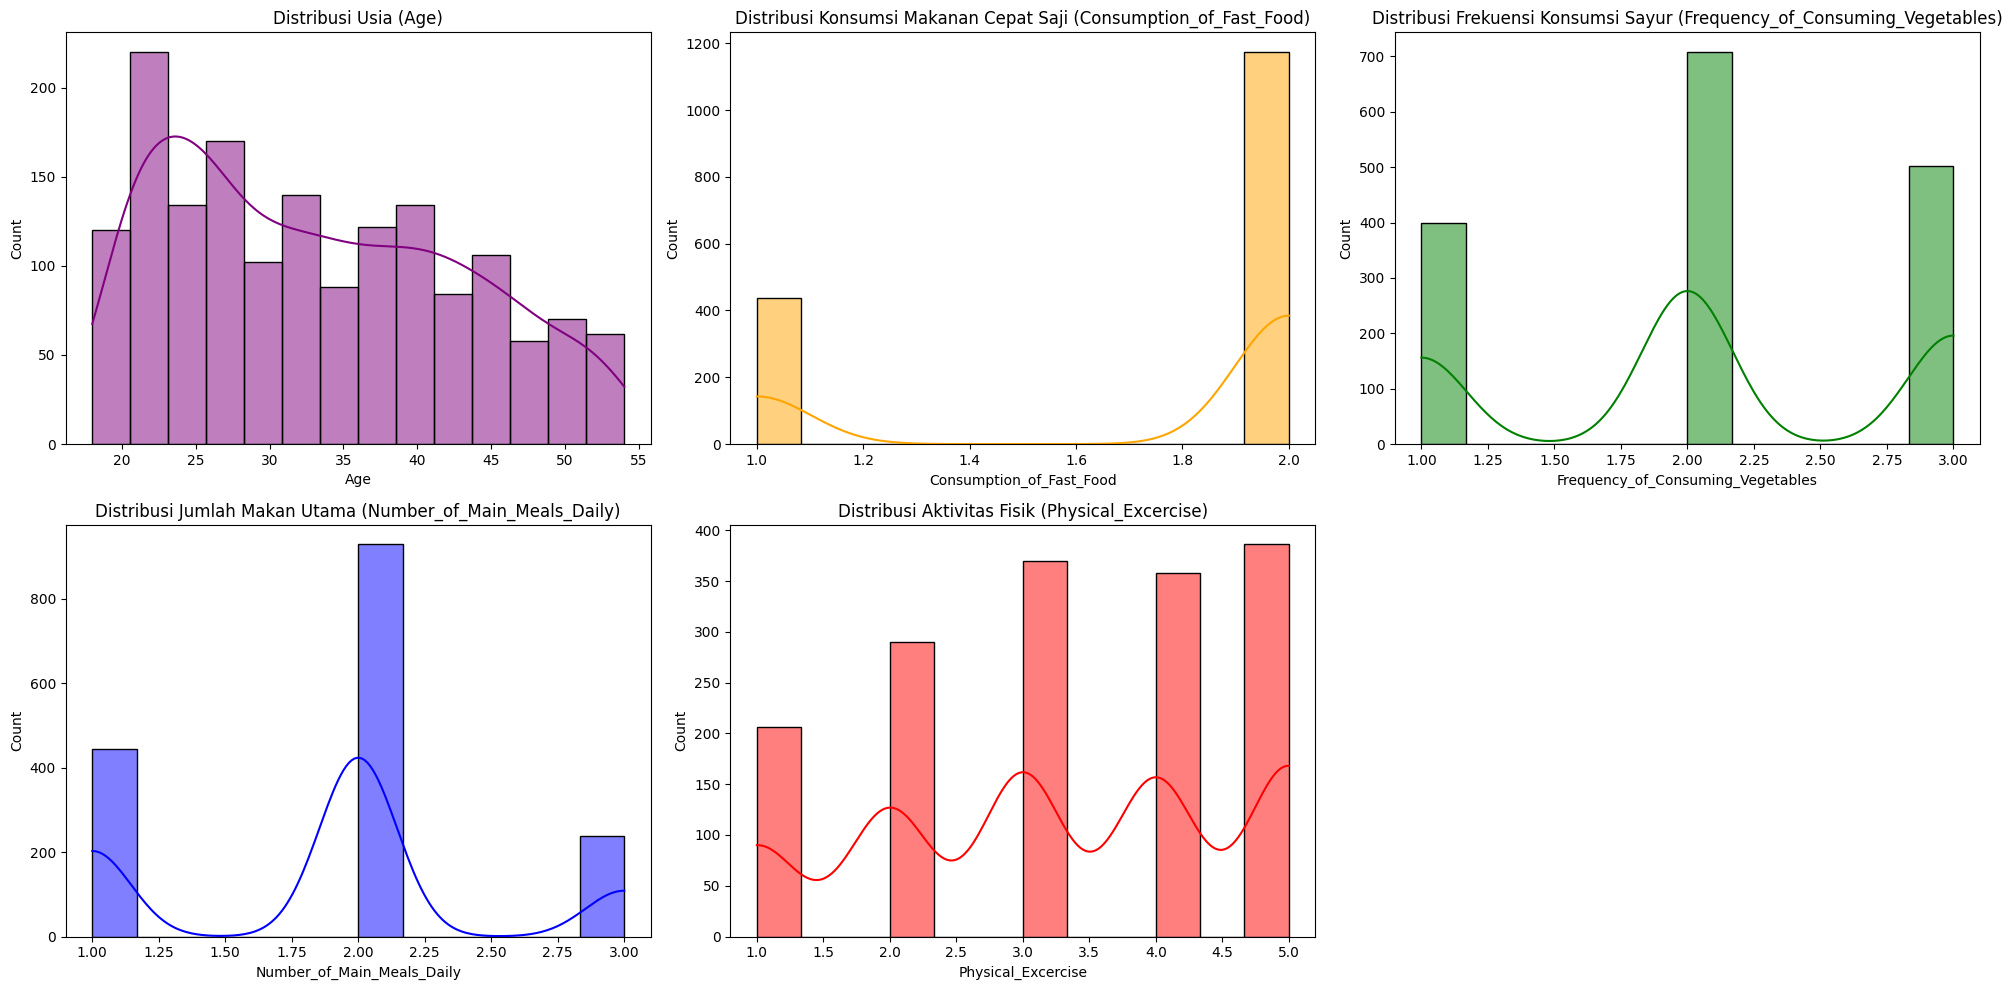

In [17]:
# Visualisasi distribusi atribut-atribut
plt.figure(figsize=(20, 10))

# Distribusi Age
plt.subplot(2, 3, 1)
sns.histplot(data=df, x='Age', kde=True, color='purple')
plt.title('Distribusi Usia (Age)')

# Distribusi Consumption_of_Fast_Food
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='Consumption_of_Fast_Food', kde=True, color='orange')
plt.title('Distribusi Konsumsi Makanan Cepat Saji (Consumption_of_Fast_Food)')

# Distribusi Frequency_of_Consuming_Vegetables
plt.subplot(2, 3, 3)
sns.histplot(data=df, x='Frequency_of_Consuming_Vegetables', kde=True, color='green')
plt.title('Distribusi Frekuensi Konsumsi Sayur (Frequency_of_Consuming_Vegetables)')

# Distribusi Number_of_Main_Meals_Daily
plt.subplot(2, 3, 4)
sns.histplot(data=df, x='Number_of_Main_Meals_Daily', kde=True, color='blue')
plt.title('Distribusi Jumlah Makan Utama (Number_of_Main_Meals_Daily)')

# Distribusi Physical_Excercise
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='Physical_Excercise', kde=True, color='red')
plt.title('Distribusi Aktivitas Fisik (Physical_Excercise)')

# Menampilkan visualisasi
plt.tight_layout()
plt.show()

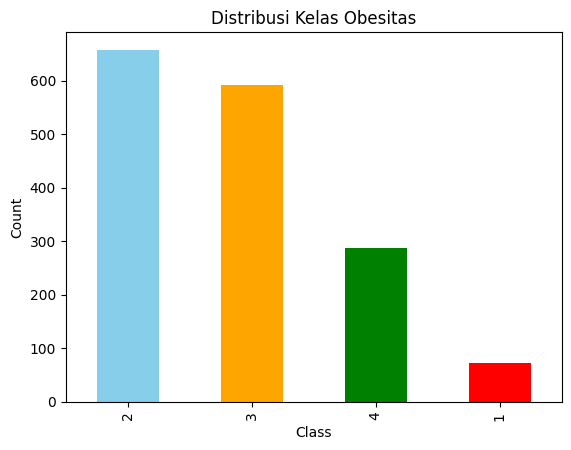

In [18]:
# visualisasi distribusi Class
# value_counts() : menghitung berapa banyak setiap kategori dalam kolom "Class"
# plot(kind='bar') : utk membuat grafik batang

df['Class'].value_counts().plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])
plt.title('Distribusi Kelas Obesitas')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

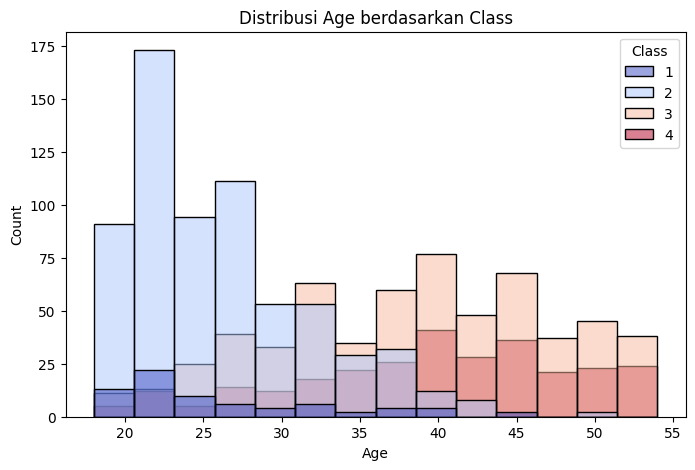

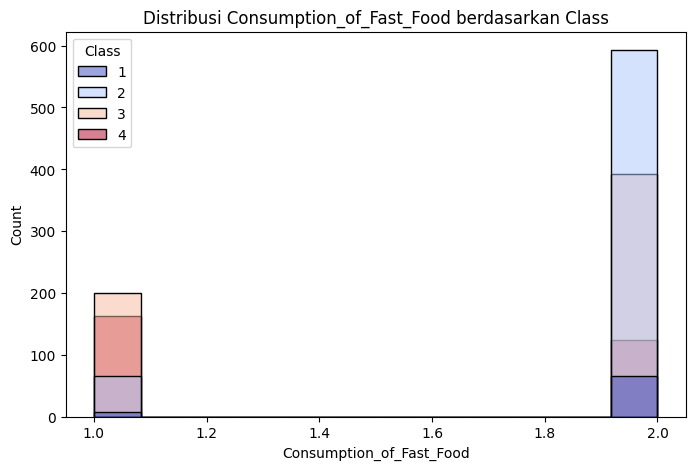

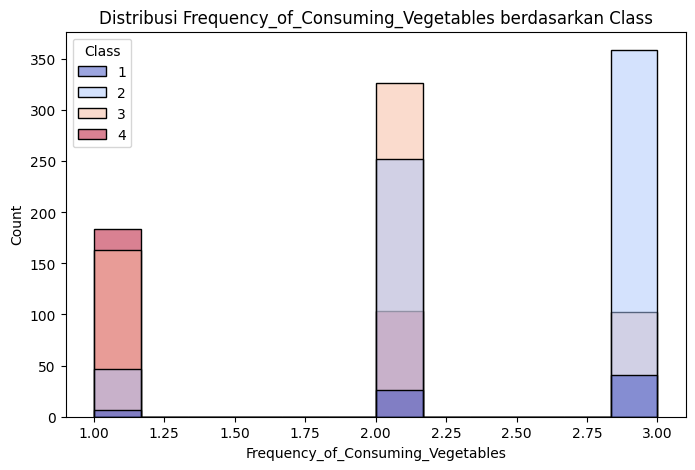

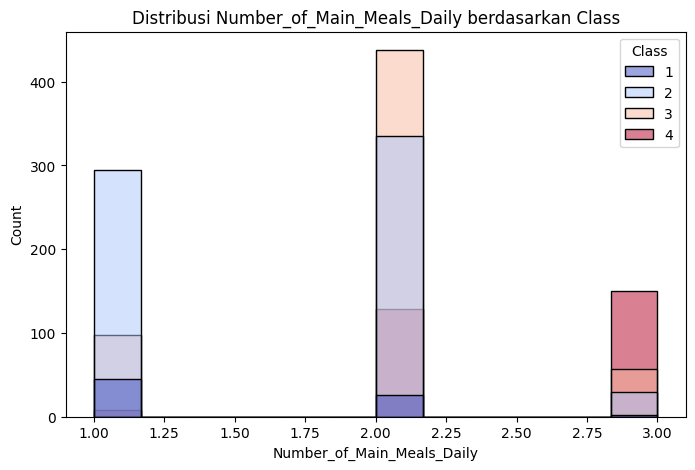

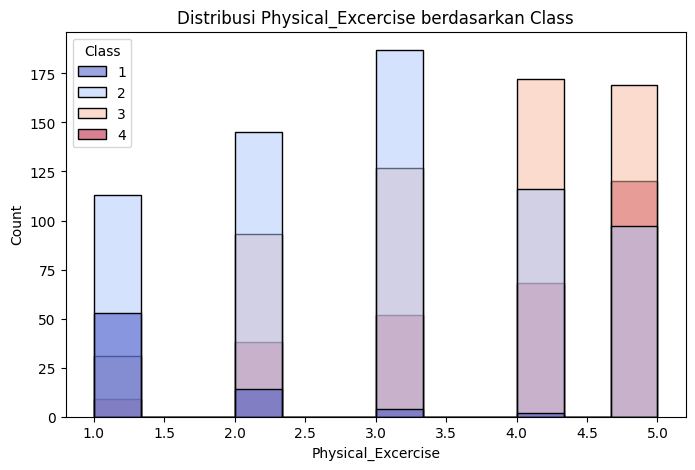

In [19]:
# Distribusi atribut yang digunakan dengan Class
relevant_features = ['Age', 'Consumption_of_Fast_Food', 'Frequency_of_Consuming_Vegetables', 'Number_of_Main_Meals_Daily', 'Physical_Excercise']

for i in relevant_features:
    plt.figure(figsize=(8,5))
    sns.histplot(data = df, x = i , hue = 'Class', palette = 'coolwarm')
    plt.title(f'Distribusi {i} berdasarkan Class')
    plt.show()

Pada distribusi class di atas, menunjukkan bahwa penyebaran data tidak merata/inbalanced data. Data yg inbalanced mempengaruhi kinerja model karena model cenderung memberikan perhatian yang lebih besar atau membuat keputusan yang tidak seimbang terhadap kelas mayorias. Untuk menyeimbangkan distribusi Class maka dilakukan feature engineering  (fitur-fitur dlm dataset diidentifikasi, dibuat, diubah, atau dipilih utk meningkatkan kinerja model) dan oversampling (menambahkan jumlah data kelas minoritas) dengan teknik SMOTE


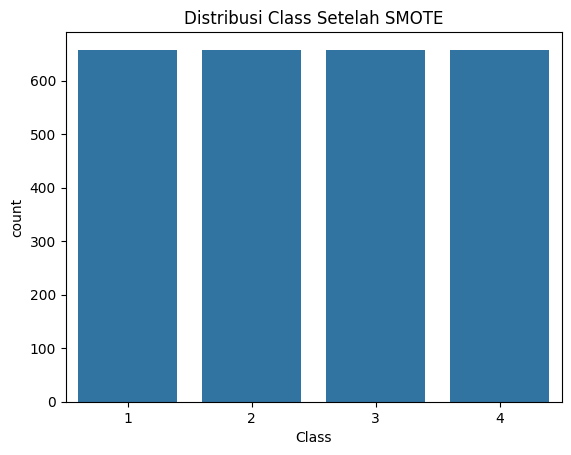

In [20]:
# Memisahkan fitur (x) dan target (y)
X_fix = df_fix.iloc[:, :-1] #memisahkan antara semua kolom dengan kolom terakhir untuk dijadikan fitur independen (x)
y_fix = df_fix.iloc[:, -1] #mengambil kolom terakhir sebagai target/label yg akan diprediksi (y)

# Oversampling menggunakan SMOTE
smote = SMOTE(random_state = 42) #membuat objek SMOTE dengan random_state agar hasil oversampling dapat direproduksi
X_resampled, y_resampled = smote.fit_resample(X_fix,y_fix)

y_resampled = pd.Series(y_resampled, name='Class')
sns.countplot(data=pd.DataFrame({'Class': y_resampled}), x='Class')  # Perbaikan visualisasi
plt.title("Distribusi Class Setelah SMOTE")
plt.show()

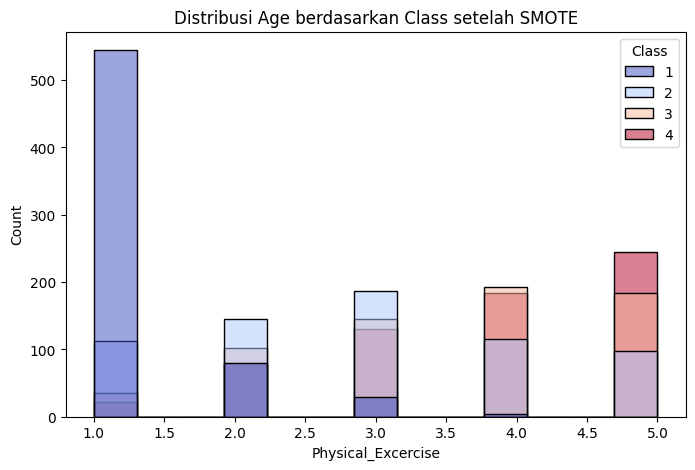

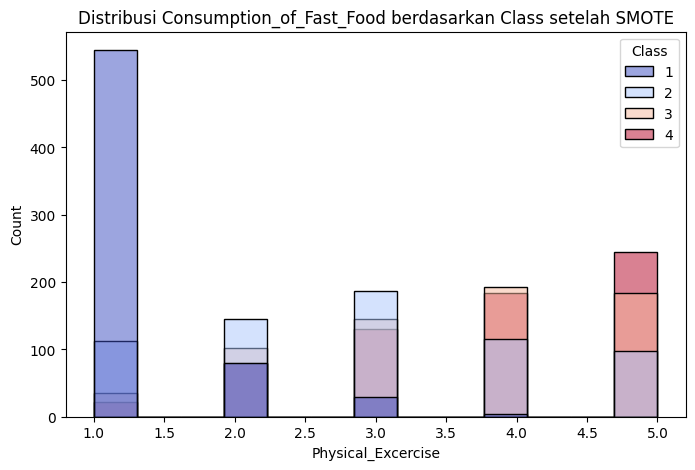

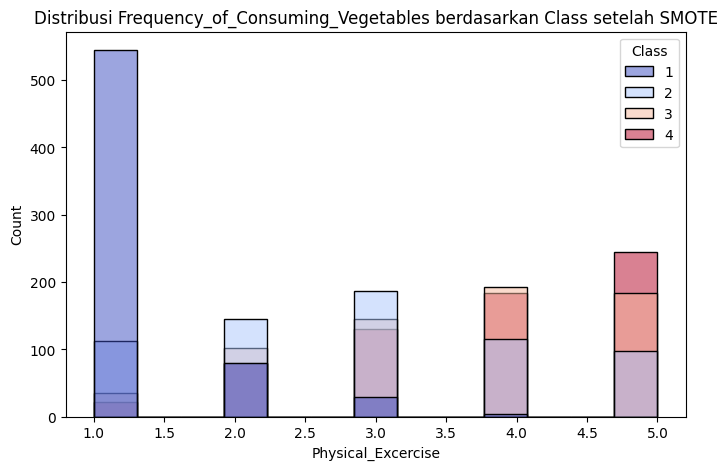

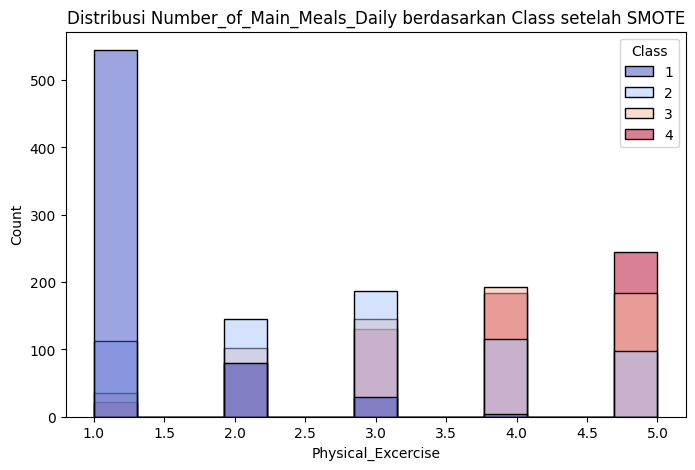

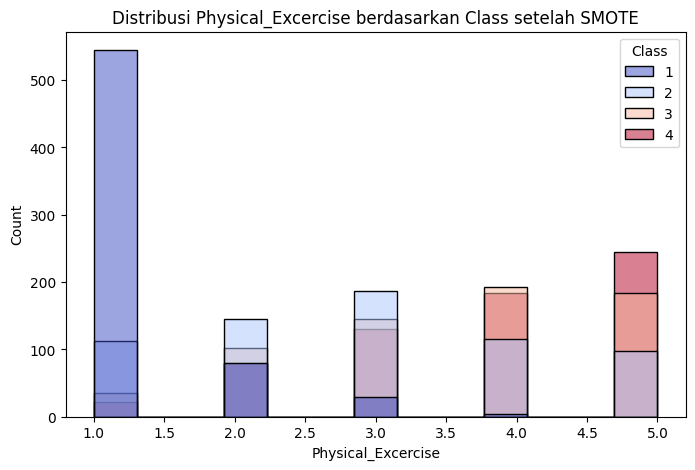

In [21]:
# Visualisasi distribusi atribut dengan Class setelah SMOTE
relevant_features = ['Age', 'Consumption_of_Fast_Food', 'Frequency_of_Consuming_Vegetables',
                     'Number_of_Main_Meals_Daily', 'Physical_Excercise']

for feature in relevant_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=pd.DataFrame(X_resampled, columns=relevant_features), x=i,
                 hue=y_resampled, palette='coolwarm')
    plt.title(f'Distribusi {feature} berdasarkan Class setelah SMOTE')
    plt.show()


In [22]:
# Membagi dataset menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Dimensi data setelah pembagian:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensi data setelah pembagian:
X_train: (2105, 5), y_train: (2105,)
X_test: (527, 5), y_test: (527,)


In [23]:
# Menyiapkan model Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Melakukan cross-validation untuk mengevaluasi model
# cv=5 artinya menggunakan 5-fold cross-validation
cv_scores = cross_val_score(dt, X_resampled, y_resampled, cv=5, scoring='accuracy')

# Menampilkan hasil cross-validation
print(f"Cross-validation scores (5-fold): {cv_scores}")
print(f"Rata-rata akurasi cross-validation: {np.mean(cv_scores):.4f}")

Cross-validation scores (5-fold): [0.85388994 0.87666034 0.88212928 0.85741445 0.86501901]
Rata-rata akurasi cross-validation: 0.8670


In [24]:
# Hyperparameter tuning dengan GridSearchCV
# Menentukan grid parameter yang ingin diuji
param_grid = {
    'max_depth': [None, 10, 20, 30],  # Kedalaman maksimum pohon keputusan
    'min_samples_split': [2, 5, 10],  # Minimal jumlah sampel untuk memecah node
    'min_samples_leaf': [1, 2, 4],    # Minimal jumlah sampel di daun
    'criterion': ['entropy'],  # Kriteria pembagian: Entropy karena menggunakan teknik C4.5
}

# Menyusun GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Melatih model menggunakan GridSearchCV
grid_search.fit(X_train, y_train)

# Menampilkan hasil terbaik dari grid search
print("Best hyperparameters:", grid_search.best_params_)

# Menggunakan model terbaik untuk prediksi
best_dt = grid_search.best_estimator_

# # Prediksi pada data testing
# y_pred = best_dt.predict(X_test)

# # Evaluasi akurasi
# accuracy = accuracy_score(y_test, y_pred)
# print("Akurasi pada data testing: ", accuracy)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}





*   GridSearchCV melakukan evaluasi terhadap 36 kombinasi hyperparameter, valuasi dilakukan dengan 5-fold cross-validation untuk setiap kombinasi parameter, sehingga totalnya ada 180 evaluasi model.
*   Kombinasi hyperparameter terbaik adalah: criterion: 'entropy', max_depth: None (pohon dibiarkan tumbuh hingga kedalaman maksimal tanpa batasan), min_samples_leaf: 1 (setiap daun pohon minimal memiliki 1 sampel), min_samples_split: 2 (cetiap node minimal memiliki 2 sampel untuk dilakukan pembagian/split)
*   Akurasi terbaik pada data validasi saat menggunakan kombinasi hyperparameter terbaik adalah sekitar 83.23% (performa model sebelum diuji pada data testing)
<br>
model Decision Tree telah dioptimalkan menggunakan teknik hyperparameter tuning dan memberikan akurasi yang cukup baik pada data validasi (cross-validation). Kombinasi hyperparameter terbaik (criterion='entropy', max_depth=None, dll.) menunjukkan bahwa model dapat bekerja maksimal tanpa batasan kedalaman dan pembagian minimal yang sangat kecil.


In [25]:
# Evaluasi model
# Prediksi pada data testing
y_pred = best_dt.predict(X_test)

# Evaluasi akurasi
print("Akurasi pada data testing: ", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi pada data testing:  0.8349146110056926

Classification Report:
               precision    recall  f1-score   support

           1       0.89      1.00      0.94       124
           2       0.79      0.82      0.80       126
           3       0.78      0.67      0.72       138
           4       0.87      0.86      0.87       139

    accuracy                           0.83       527
   macro avg       0.83      0.84      0.83       527
weighted avg       0.83      0.83      0.83       527




Precision, Recall, dan F1-Score
*   Kelas 1 (underweight) memiliki precision dan recall yang sangat baik, dengan F1-score yang tinggi (0.94)
*   Item daftar



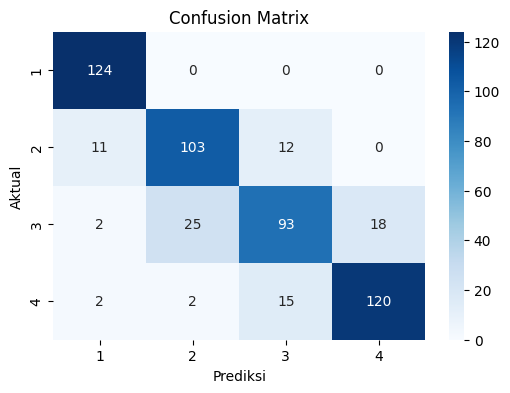

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_dt.classes_, yticklabels=best_dt.classes_)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

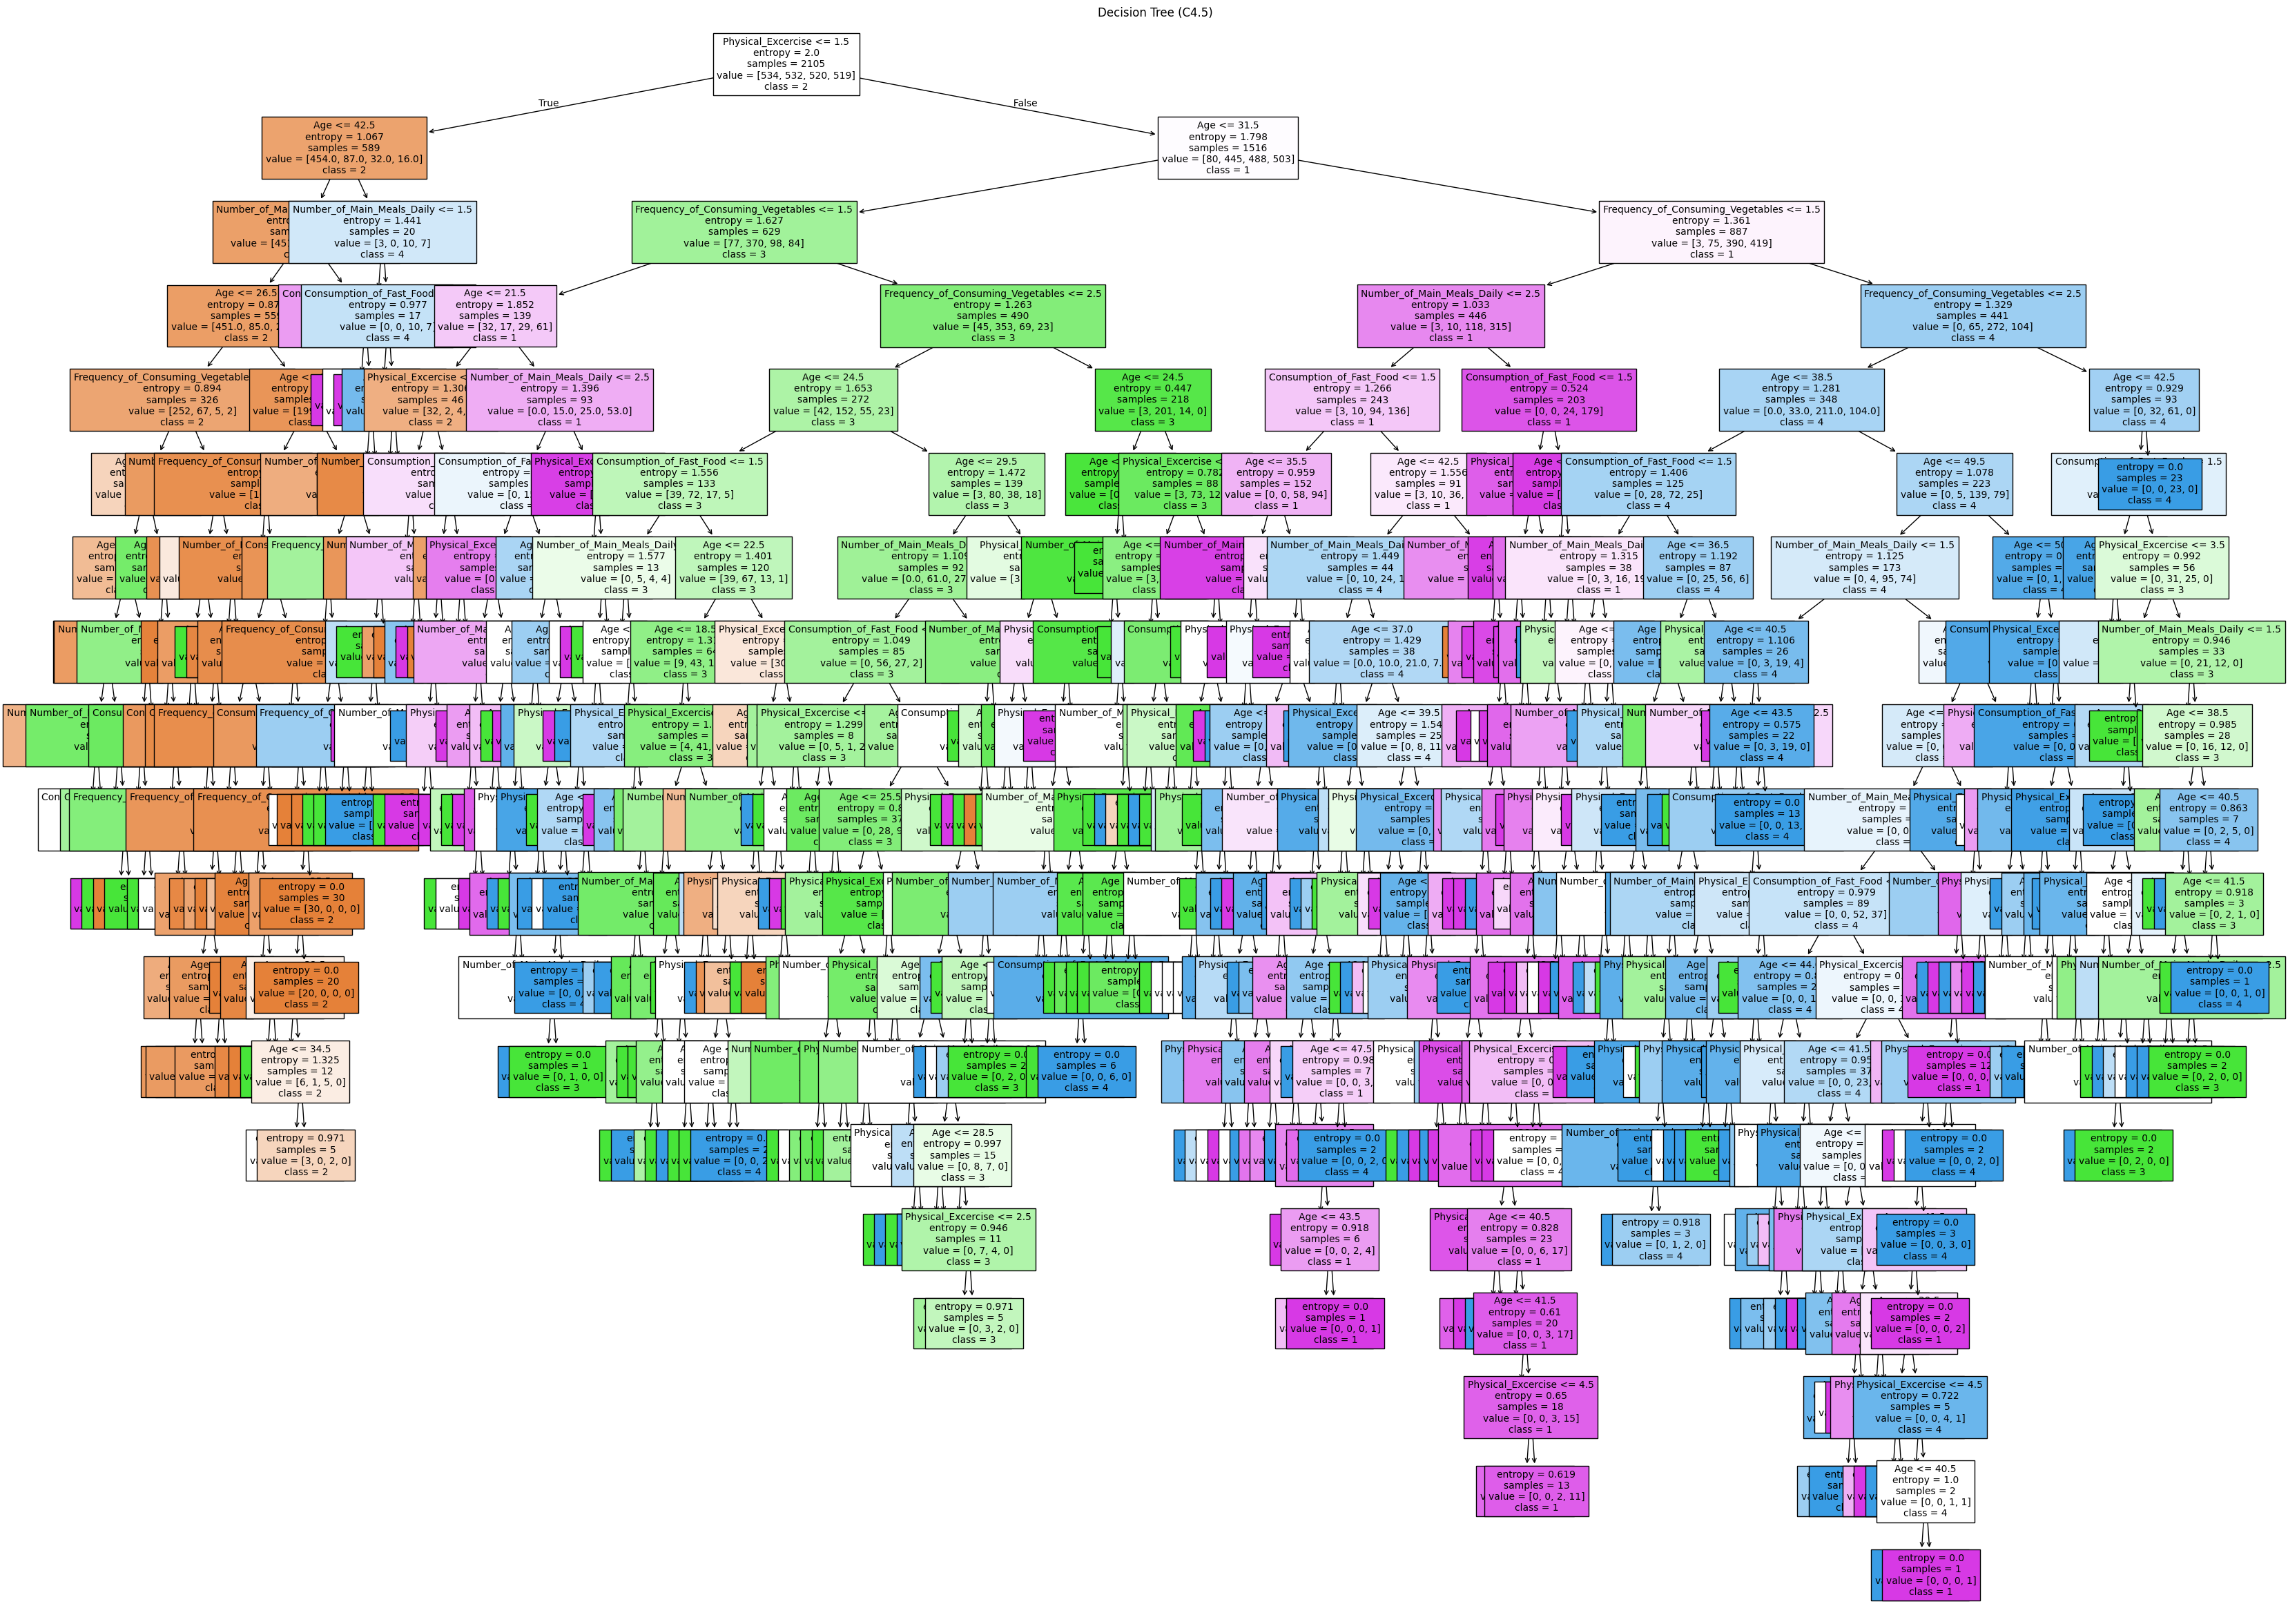

In [27]:
feature_names = ['Age', 'Consumption_of_Fast_Food', 'Frequency_of_Consuming_Vegetables',
                 'Number_of_Main_Meals_Daily', 'Physical_Excercise']
class_names = y_resampled.unique().astype(str)  # Nama kelas

plt.figure(figsize=(40,30))
tree.plot_tree(best_dt, feature_names=feature_names, class_names=class_names, filled=True, fontsize=10)
plt.title("Decision Tree (C4.5)")
plt.show()

In [31]:
import pickle
# Simpan model ke file
with open('model_obesitas.pkl', 'wb') as model_file:
    pickle.dump(best_dt.predict, model_file)

print("Model berhasil disimpan ke file 'model_obesitas'")

Model berhasil disimpan ke file 'model_obesitas'


In [32]:
from IPython.display import FileLink

# Tampilkan tautan unduh
FileLink('model_obesitas.pkl')

/content/model_obesitas.pkl